# 1. Install dependencies

In [13]:
!pip -q install torch torchvision torchaudio
!pip -q install opencv-python
!pip -q install numpy
!pip -q install pandas
!pip -q install matplotlib
!pip -q install seaborn
!pip -q install scikit-learn
!pip -q install scikit-image
!pip -q install tqdm
!pip -q install nibabel
!pip -q install medpy
!pip -q install git+https://github.com/facebookresearch/segment-anything.git


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip i

# 2. Imports

In [14]:
import os
import cv2
import json
import math
import torch
import random
import numpy as np
import pandas as pd
import nibabel as nib
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from skimage.measure import label
from skimage.measure import regionprops

from medpy.metric.binary import dc
from medpy.metric.binary import hd95

from segment_anything import sam_model_registry
from segment_anything import SamPredictor

# 3. Experiment configuration

In [15]:
CONFIG = {

    "seed": 42,

    "brats_root": "/workspace/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData",

    "dataset_dir": "/workspace/dataset",

    "results_dir": "/workspace/results",

    "checkpoint_dir": "/workspace/checkpoints",

    "sam_checkpoint": "/workspace/sam_vit_b_01ec64.pth",

    "sam_model_type": "vit_b",

    "num_uncertainty_samples": 5,

    "prompt_noise": 8,

    "device": "cuda" if torch.cuda.is_available() else "cpu"
}

print(CONFIG)

{'seed': 42, 'brats_root': '/workspace/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData', 'dataset_dir': '/workspace/dataset', 'results_dir': '/workspace/results', 'checkpoint_dir': '/workspace/checkpoints', 'sam_checkpoint': '/workspace/sam_vit_b_01ec64.pth', 'sam_model_type': 'vit_b', 'num_uncertainty_samples': 5, 'prompt_noise': 8, 'device': 'cuda'}


# 4. Reproducibility

In [16]:
def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_seed(CONFIG["seed"])

# 5. Create experiment folders

In [17]:
os.makedirs(CONFIG["dataset_dir"], exist_ok=True)
os.makedirs(CONFIG["results_dir"], exist_ok=True)
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)

os.makedirs(f"{CONFIG['results_dir']}/images", exist_ok=True)
os.makedirs(f"{CONFIG['results_dir']}/plots", exist_ok=True)
os.makedirs(f"{CONFIG['results_dir']}/metrics", exist_ok=True)
os.makedirs(f"{CONFIG['results_dir']}/uncertainty", exist_ok=True)

# 6. Dataset preprocessing (BraTS → slices)

In [18]:
dataset_root = CONFIG["brats_root"]
output_dir = CONFIG["dataset_dir"]

cases = [os.path.join(dataset_root,c) for c in os.listdir(dataset_root)]

slice_index = 0

for case in tqdm(cases):

    # We ensure that only patient directories are processed.
    if not os.path.isdir(case):
        continue

    flair_path = None
    seg_path = None

    for f in os.listdir(case):

        if "flair" in f.lower():
            flair_path = os.path.join(case,f)

        if "seg" in f.lower():
            seg_path = os.path.join(case,f)

    if flair_path is None or seg_path is None:
        continue

    flair = nib.load(flair_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()

    for z in range(flair.shape[2]):

        img = flair[:,:,z]
        mask = seg[:,:,z]

        if np.sum(mask)==0:
            continue

        img_norm = cv2.normalize(img,None,0,255,cv2.NORM_MINMAX)
        img_norm = img_norm.astype(np.uint8)

        mask_bin = (mask>0).astype(np.uint8)*255

        img_file = os.path.join(output_dir,f"img_{slice_index}.png")
        mask_file = os.path.join(output_dir,f"img_{slice_index}_mask.png")

        cv2.imwrite(img_file,img_norm)
        cv2.imwrite(mask_file,mask_bin)

        slice_index += 1

print("Total slices:",slice_index)

100%|██████████| 204/204 [00:18<00:00, 11.26it/s]

Total slices: 13535


# 7. Dataset loading

In [19]:
images=[]
masks=[]

for f in os.listdir(CONFIG["dataset_dir"]):

    if f.endswith(".png") and "mask" not in f:

        img_path=os.path.join(CONFIG["dataset_dir"],f)
        mask_path=img_path.replace(".png","_mask.png")

        if os.path.exists(mask_path):

            images.append(img_path)
            masks.append(mask_path)

print("Total samples:",len(images))

Total samples: 13535


# 8. Train / test split

In [20]:
train_images,test_images,train_masks,test_masks = train_test_split(
    images,
    masks,
    test_size=0.2,
    random_state=CONFIG["seed"]
)

print("Train:",len(train_images))
print("Test:",len(test_images))

Train: 10828
Test: 2707


# 9. Load SAM

In [22]:
sam = sam_model_registry[CONFIG["sam_model_type"]](checkpoint=CONFIG["sam_checkpoint"])
sam.to(CONFIG["device"])

predictor = SamPredictor(sam)

print("SAM loaded")

SAM loaded


# 10. Bounding box extraction

In [23]:
def get_bbox_from_mask(mask):

    labeled = label(mask)

    props = regionprops(labeled)

    if len(props)==0:
        return None

    largest = max(props,key=lambda x:x.area)

    minr,minc,maxr,maxc = largest.bbox

    return np.array([minc,minr,maxc,maxr])

# 11. SAM inference

In [24]:
def run_sam(image,box):

    predictor.set_image(image)

    masks,scores,logits = predictor.predict(
        box=box[None,:],
        multimask_output=False
    )

    return masks[0], logits[0]

# 12. Uncertainty estimation

In [25]:
def compute_uncertainty(image,box):

    probs=[]

    for i in range(CONFIG["num_uncertainty_samples"]):

        noise=np.random.randint(-CONFIG["prompt_noise"],CONFIG["prompt_noise"],4)

        noisy_box=box+noise

        mask,logit=run_sam(image,noisy_box)

        prob = 1 / (1 + np.exp(-np.clip(logit, -50, 50)))

        probs.append(prob)

    probs=np.stack(probs)

    variance=np.var(probs,axis=0)

    entropy=-(probs*np.log(probs+1e-6)+(1-probs)*np.log(1-probs+1e-6))
    entropy=np.mean(entropy,axis=0)

    return variance,entropy

# 13. Prompt refinement

In [26]:
def refine_prompts(variance,entropy):

    u=variance+entropy

    thresh=np.percentile(u,97)

    coords=np.column_stack(np.where(u>thresh))

    if len(coords)==0:
        return None,None

    k=min(5,len(coords))

    idx=np.random.choice(len(coords),k,replace=False)

    pts=coords[idx]

    points=[]
    labels=[]

    for y,x in pts:

        points.append([x,y])
        labels.append(1)

    return np.array(points),np.array(labels)

# 14. Evaluation metrics

In [27]:
def compute_metrics(gt,pred):

    gt=gt.flatten()
    pred=pred.flatten()

    dice=dc(pred,gt)

    precision=precision_score(gt,pred)
    recall=recall_score(gt,pred)
    f1=f1_score(gt,pred)

    cm=confusion_matrix(gt,pred)

    try:
        auroc=roc_auc_score(gt,pred)
    except:
        auroc=np.nan

    try:
        auprc=average_precision_score(gt,pred)
    except:
        auprc=np.nan

    return {

        "dice":dice,
        "precision":precision,
        "recall":recall,
        "f1":f1,
        "auroc":auroc,
        "auprc":auprc,
        "confusion_matrix":cm
    }

# 15. Experiment loop

In [28]:
metrics_list=[]

for img_path,mask_path in tqdm(list(zip(test_images,test_masks))):

    img=cv2.imread(img_path)
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

    gt=cv2.imread(mask_path,0)
    gt=(gt>0).astype(np.uint8)

    box=get_bbox_from_mask(gt)

    if box is None:
        continue

    baseline,_=run_sam(img,box)

    variance,entropy=compute_uncertainty(img,box)

    points,labels=refine_prompts(variance,entropy)

    predictor.set_image(img)

    masks,_,_=predictor.predict(
        point_coords=points,
        point_labels=labels,
        box=box[None,:],
        multimask_output=False
    )

    refined=masks[0]

    m=compute_metrics(gt,refined)

    metrics_list.append(m)

100%|██████████| 2707/2707 [31:29<00:00,  1.43it/s]


# 16. Save metrics

In [29]:
metrics_df=pd.DataFrame(metrics_list)

metrics_df.to_csv(f"{CONFIG['results_dir']}/metrics/metrics.csv",index=False)

print(metrics_df.describe())

              dice    precision       recall           f1        auroc  \
count  2707.000000  2707.000000  2707.000000  2707.000000  2707.000000   
mean      0.525178     0.419835     0.907323     0.525178     0.920098   
std       0.289860     0.266700     0.201749     0.289860     0.150061   
min       0.000000     0.000000     0.000000     0.000000     0.012191   
25%       0.309561     0.186567     0.927668     0.309561     0.931127   
50%       0.613718     0.458171     0.984021     0.613718     0.970589   
75%       0.757449     0.628090     0.998614     0.757449     0.982447   
max       0.980692     0.999093     1.000000     0.980692     0.998628   

             auprc  
count  2707.000000  
mean      0.398506  
std       0.257677  
min       0.000017  
25%       0.170670  
50%       0.434050  
75%       0.602813  
max       0.962153  


# 17. Dice distribution plot

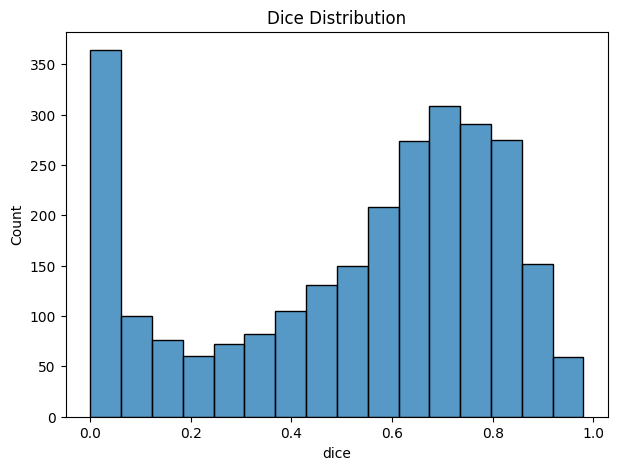

In [30]:
plt.figure(figsize=(7,5))

sns.histplot(metrics_df["dice"])

plt.title("Dice Distribution")

plt.savefig(f"{CONFIG['results_dir']}/plots/dice_distribution.png")

plt.show()

# 18. Confusion matrix

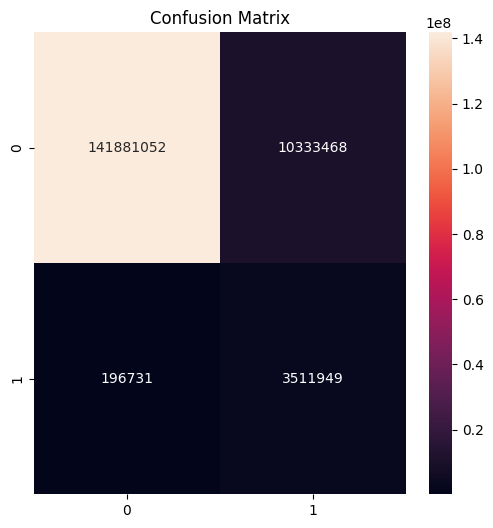

In [31]:
cm=np.sum(metrics_df["confusion_matrix"].tolist(),axis=0)

plt.figure(figsize=(6,6))

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.savefig(f"{CONFIG['results_dir']}/plots/confusion_matrix.png")

plt.show()

# 19. Prompt sensitivity experiment

In [32]:
prompt_counts=[1,2,3,5,8]

dice_scores=[]

for n in prompt_counts:

    scores=[]

    for img_path,mask_path in zip(test_images,test_masks):

        img=cv2.imread(img_path)
        img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

        gt=cv2.imread(mask_path,0)
        gt=(gt>0).astype(np.uint8)

        box=get_bbox_from_mask(gt)

        predictor.set_image(img)

        pts=[]
        labels=[]

        for i in range(n):

            x=random.randint(box[0],box[2])
            y=random.randint(box[1],box[3])

            pts.append([x,y])
            labels.append(1)

        pts=np.array(pts)
        labels=np.array(labels)

        masks,_,_=predictor.predict(
            point_coords=pts,
            point_labels=labels,
            box=box[None,:],
            multimask_output=False
        )

        pred=masks[0]

        scores.append(dc(pred,gt))

    dice_scores.append(np.mean(scores))

# 20. Prompt sensitivity plot

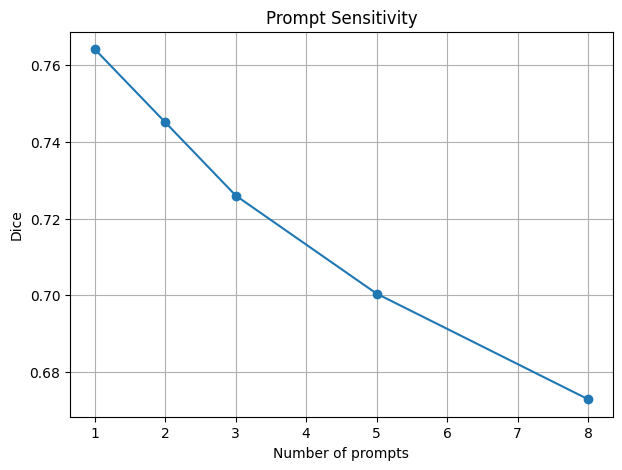

In [33]:
plt.figure(figsize=(7,5))

plt.plot(prompt_counts,dice_scores,marker="o")

plt.xlabel("Number of prompts")
plt.ylabel("Dice")

plt.title("Prompt Sensitivity")

plt.grid()

plt.savefig(f"{CONFIG['results_dir']}/plots/prompt_sensitivity.png")

plt.show()

# 21. Viewing Dice Scores

In [34]:
print("Prompt counts:", prompt_counts)
print("Dice scores:", dice_scores)

for p, d in zip(prompt_counts, dice_scores):
    print(f"{p} prompts → Dice = {d:.4f}")

Prompt counts: [1, 2, 3, 5, 8]
Dice scores: [np.float64(0.7642160303846285), np.float64(0.7451342343691124), np.float64(0.7260193703126264), np.float64(0.700407127487453), np.float64(0.6728412762310324)]
1 prompts → Dice = 0.7642
2 prompts → Dice = 0.7451
3 prompts → Dice = 0.7260
5 prompts → Dice = 0.7004
8 prompts → Dice = 0.6728


# 22. Viewing Metrics

In [36]:
df = pd.read_csv("/workspace/results/metrics/metrics.csv")

print(df.describe())

print("Mean Dice:", df["dice"].mean())
print("Median Dice:", df["dice"].median())

print("Dice > 0.7:", (df["dice"] > 0.7).sum())
print("Dice < 0.1:", (df["dice"] < 0.1).sum())

              dice    precision       recall           f1        auroc  \
count  2707.000000  2707.000000  2707.000000  2707.000000  2707.000000   
mean      0.525178     0.419835     0.907323     0.525178     0.920098   
std       0.289860     0.266700     0.201749     0.289860     0.150061   
min       0.000000     0.000000     0.000000     0.000000     0.012191   
25%       0.309561     0.186567     0.927668     0.309561     0.931127   
50%       0.613718     0.458171     0.984021     0.613718     0.970589   
75%       0.757449     0.628090     0.998614     0.757449     0.982447   
max       0.980692     0.999093     1.000000     0.980692     0.998628   

             auprc  
count  2707.000000  
mean      0.398506  
std       0.257677  
min       0.000017  
25%       0.170670  
50%       0.434050  
75%       0.602813  
max       0.962153  
Mean Dice: 0.5251781148176413
Median Dice: 0.6137184115523465
Dice > 0.7: 942
Dice < 0.1: 433


# 23. Boundary-Uncertainty Prompt Generator

In [37]:
def boundary_uncertainty_prompts(variance, entropy, k=5):

    u = variance + entropy

    thresh = np.percentile(u, 97)

    coords = np.column_stack(np.where(u > thresh))

    if len(coords) == 0:
        return None, None

    idx = np.random.choice(len(coords), min(k, len(coords)), replace=False)

    pts = coords[idx]

    points = []
    labels = []

    for y, x in pts:

        points.append([x, y])
        labels.append(1)

    return np.array(points), np.array(labels)

# 24. Uncertainty-Guided Prompt Experiment

In [38]:
uncertainty_scores = []
random_scores = []
box_scores = []

for img_path, mask_path in tqdm(list(zip(test_images, test_masks))):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    gt = cv2.imread(mask_path,0)
    gt = (gt > 0).astype(np.uint8)

    box = get_bbox_from_mask(gt)

    if box is None:
        continue

    # baseline box
    baseline,_ = run_sam(img,box)
    box_scores.append(dc(baseline,gt))

    # uncertainty map
    variance,entropy = compute_uncertainty(img,box)

    # uncertainty prompts
    points,labels = boundary_uncertainty_prompts(variance,entropy)

    if points is not None:

        predictor.set_image(img)

        masks,_,_ = predictor.predict(
            point_coords=points,
            point_labels=labels,
            box=box[None,:],
            multimask_output=False
        )

        pred = masks[0]

        uncertainty_scores.append(dc(pred,gt))

    # random prompts
    pts=[]
    lbl=[]

    for i in range(5):

        x=random.randint(box[0],box[2])
        y=random.randint(box[1],box[3])

        pts.append([x,y])
        lbl.append(1)

    pts=np.array(pts)
    lbl=np.array(lbl)

    predictor.set_image(img)

    masks,_,_=predictor.predict(
        point_coords=pts,
        point_labels=lbl,
        box=box[None,:],
        multimask_output=False
    )

    pred=masks[0]

    random_scores.append(dc(pred,gt))

100%|██████████| 2707/2707 [34:53<00:00,  1.29it/s]


# 25. Compare the Three Methods

In [39]:
print("Bounding Box Dice:", np.mean(box_scores))
print("Random Prompt Dice:", np.mean(random_scores))
print("Uncertainty Prompt Dice:", np.mean(uncertainty_scores))

Bounding Box Dice: 0.7881034163441262
Random Prompt Dice: 0.7006535236303071
Uncertainty Prompt Dice: 0.5237782098445136


# 26. Plot the Comparison

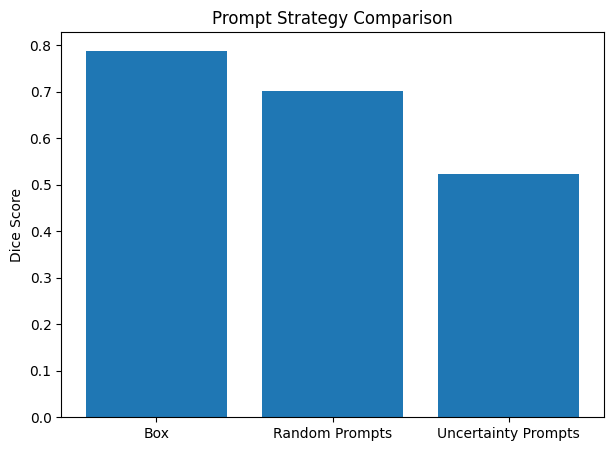

In [40]:
methods = ["Box", "Random Prompts", "Uncertainty Prompts"]

scores = [
    np.mean(box_scores),
    np.mean(random_scores),
    np.mean(uncertainty_scores)
]

plt.figure(figsize=(7,5))

plt.bar(methods, scores)

plt.ylabel("Dice Score")

plt.title("Prompt Strategy Comparison")

plt.savefig(f"{CONFIG['results_dir']}/plots/prompt_strategy_comparison.png")

plt.show()

# 27. Case-Level Dice Calculation

In [42]:
import pandas as pd
import os

df = pd.read_csv("/workspace/results/metrics/metrics.csv")

# attach image paths again
df["image_path"] = test_images[:len(df)]

def extract_case(path):
    parts = path.split("/")
    for p in parts:
        if "BraTS20_Training_" in p:
            return p
    return "unknown"

df["case"] = df["image_path"].apply(extract_case)

case_dice = df.groupby("case")["dice"].mean()

print("Number of cases:", len(case_dice))
print("Mean Case Dice:", case_dice.mean())
print("Median Case Dice:", case_dice.median())

case_dice.describe()

Number of cases: 1
Mean Case Dice: 0.5251781148176414
Median Case Dice: 0.5251781148176414


count    1.000000
mean     0.525178
std           NaN
min      0.525178
25%      0.525178
50%      0.525178
75%      0.525178
max      0.525178
Name: dice, dtype: float64

# 28. Case Dice Histogram

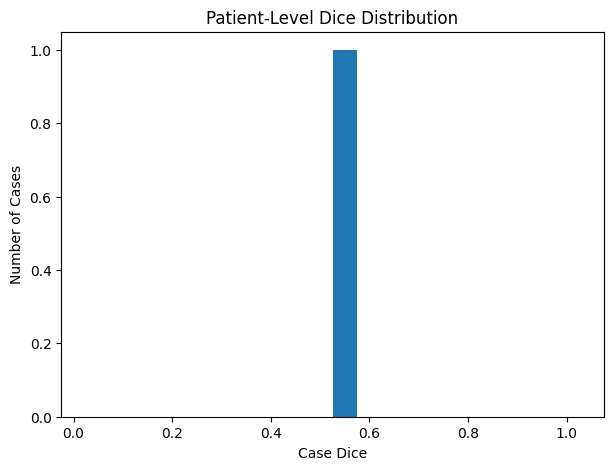

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(case_dice, bins=20)

plt.xlabel("Case Dice")
plt.ylabel("Number of Cases")
plt.title("Patient-Level Dice Distribution")

plt.savefig("/workspace/results/plots/case_dice_distribution.png")

plt.show()